# 06 – Feature Selection: Variables Seleccionadas

**Proyecto:** Encuesta Permanente de Empleo Nacional (EPEN)  
**Objetivo:** Identificar y seleccionar el subconjunto de variables más relevantes para el modelo, reduciendo la dimensionalidad y el riesgo de overfitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, mutual_info_classif, RFE
from sklearn.preprocessing import StandardScaler
import os

FE_DIR = os.path.join('..', 'data', 'feature_engineering')
try:
    df = pd.read_csv(os.path.join(FE_DIR, 'epen_fe_demographic.csv'))
except FileNotFoundError:
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame(np.random.randn(n, 15), columns=[f'feature_{i}' for i in range(15)])
    df['target_desocupado'] = np.random.choice([0, 1], n, p=[0.50, 0.50])

TARGET = 'target_desocupado'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].select_dtypes(include=np.number).fillna(0)
y = df[TARGET]

print(f'Features disponibles: {X.shape[1]}')
print(X.columns.tolist())

Features disponibles: 8
['edad', 'sexo_bin', 'nivel_educativo_ord', 'grupo_etario', 'es_joven', 'adulto_mayor_activo', 'educacion_superior', 'mujer_con_edu_superior']


## 1. Información Mutua (Mutual Information)

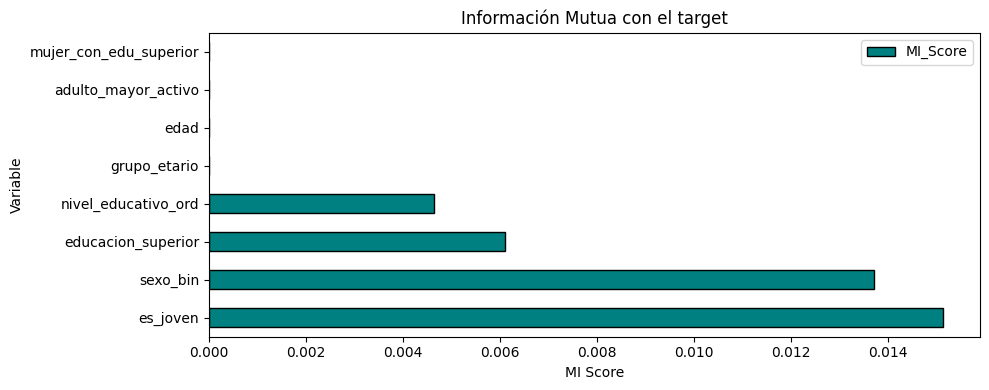

,Variable,MI_Score
0,es_joven,0.015132
1,sexo_bin,0.013709
2,educacion_superior,0.006091
3,nivel_educativo_ord,0.004645
4,grupo_etario,0.000000
5,edad,0.000000
6,adulto_mayor_activo,0.000000
7,mujer_con_edu_superior,0.000000


In [2]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Variable': X.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

mi_df.plot(x='Variable', y='MI_Score', kind='barh', color='teal',
           edgecolor='black', figsize=(10, max(4, len(X.columns) * 0.4)))
plt.title('Información Mutua con el target')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()
mi_df.head(10)

## 2. Importancia de Variables – Random Forest

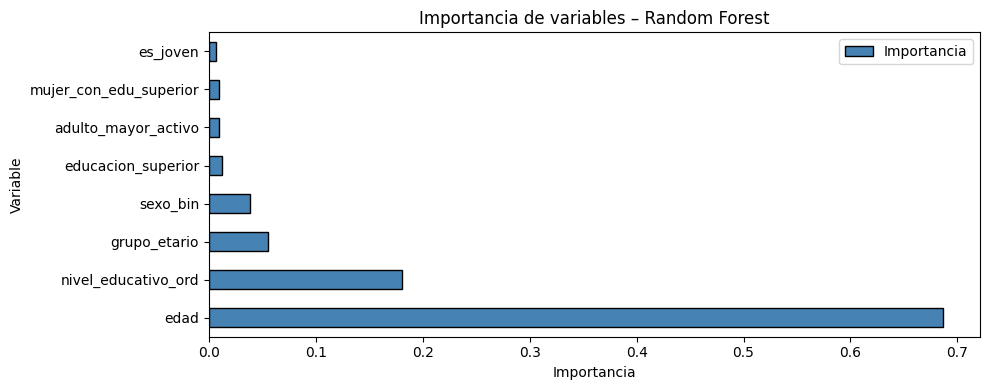

,Variable,Importancia
0,edad,0.686842
1,nivel_educativo_ord,0.180597
2,grupo_etario,0.055689
3,sexo_bin,0.038665
4,educacion_superior,0.012595
5,adulto_mayor_activo,0.009447
6,mujer_con_edu_superior,0.009229
7,es_joven,0.006936


In [3]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.DataFrame({'Variable': X.columns, 'Importancia': rf.feature_importances_})
importances = importances.sort_values('Importancia', ascending=False).reset_index(drop=True)

importances.plot(x='Variable', y='Importancia', kind='barh', color='steelblue',
                 edgecolor='black', figsize=(10, max(4, len(X.columns) * 0.4)))
plt.title('Importancia de variables – Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()
importances.head(10)

## 3. Selección automática con umbral

In [4]:
selector = SelectFromModel(rf, threshold='mean', prefit=True)
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()
print(f'Variables seleccionadas ({len(selected_features)}): {selected_features}')

Variables seleccionadas (2): ['edad', 'nivel_educativo_ord']


## 4. Guardar lista de variables seleccionadas

In [5]:
SEL_DIR = os.path.join('..', 'data', 'selected')
os.makedirs(SEL_DIR, exist_ok=True)

# Guardar la lista de features
pd.Series(selected_features, name='selected_feature').to_csv(
    os.path.join(SEL_DIR, 'selected_features.csv'), index=False
)

# Guardar dataset reducido
X_sel = X[selected_features].copy()
X_sel[TARGET] = y.values
X_sel.to_csv(os.path.join(SEL_DIR, 'epen_selected.csv'), index=False)

# Guardar tabla de importancias
importances.to_csv(os.path.join(SEL_DIR, 'feature_importances.csv'), index=False)

print('Archivos guardados en:', SEL_DIR)
print('  selected_features.csv')
print('  epen_selected.csv')
print('  feature_importances.csv')

Archivos guardados en: ..\data\selected
  selected_features.csv
  epen_selected.csv
  feature_importances.csv
